Discretization is the process of converting continuous data or functions into discrete counterparts by creating a set of contiguous intervals or categories. This technique is commonly used in various fields such as machine learning, data analysis, and numerical methods to simplify complex data and make it more manageable for analysis or modeling.

types of discretization include:
1. **Equal-width discretization**: This method divides the range of the data into equal-sized intervals. Each interval has the same width, and the number of intervals is determined by the user.
2. **Equal-frequency discretization**: This method divides the data into intervals that contain an equal number of data points. The width of the intervals may vary, but each interval will have the same number of observations.
3. **K-means discretization**: This method uses the K-means clustering algorithm to group data points into clusters, which are then treated as discrete categories. The number of clusters (K) is determined by the user.

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer


In [2]:
df=pd.read_csv('./train.csv',usecols=['Age','Fare','Survived'])
df.dropna(inplace=True)

In [3]:
X=df.iloc[:,1:]
y=df.iloc[:,0]

In [4]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

In [5]:
clf=DecisionTreeClassifier()
clf.fit(X_train,y_train)
y_pred=clf.predict(X_test)
print(accuracy_score(y_test,y_pred))

0.6223776223776224


In [6]:
np.mean(cross_val_score(clf,X,y,cv=5))

np.float64(0.6218556091795528)

In [15]:
kbin_age=KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='quantile')
kbin_fare=KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='quantile')

In [16]:
trf=ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])

In [17]:
X_train_trf=trf.fit_transform(X_train)
X_test_trf=trf.transform(X_test)

c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


In [19]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.67, 14.  , 18.  , 22.  , 25.  , 28.  , 31.  , 35.  , 42.  ,
              50.  , 80.  ])                                                ],
      dtype=object)

In [20]:
output=pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
})

In [25]:
output['age_labels']=pd.cut(x=X_train['Age'],bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels']=pd.cut(x=X_train['Fare'],bins=trf.named_transformers_['second'].bin_edges_[0].tolist()) 

In [26]:
output.sample(10)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
290,26.0,4.0,78.8500,9.0,"(25.0, 28.0]","(78.267, 512.329]"
676,24.5,3.0,8.0500,2.0,"(22.0, 25.0]","(7.896, 8.662]"
294,24.0,3.0,7.8958,2.0,"(22.0, 25.0]","(7.742, 7.896]"
687,19.0,2.0,10.1708,3.0,"(18.0, 22.0]","(8.662, 12.35]"
174,56.0,9.0,30.6958,7.0,"(50.0, 80.0]","(27.9, 39.688]"
333,16.0,1.0,18.0000,5.0,"(14.0, 18.0]","(15.5, 25.929]"
389,17.0,1.0,12.0000,3.0,"(14.0, 18.0]","(8.662, 12.35]"
827,1.0,0.0,37.0042,7.0,"(0.67, 14.0]","(27.9, 39.688]"
167,45.0,8.0,27.9000,7.0,"(42.0, 50.0]","(25.929, 27.9]"
73,26.0,4.0,14.4542,4.0,"(25.0, 28.0]","(12.35, 15.5]"


In [28]:
clf=DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2=clf.predict(X_test_trf)

In [29]:
accuracy_score(y_test,y_pred2)

0.6993006993006993

In [30]:
X_trf=trf.fit_transform(X)
np.mean(cross_val_score(clf,X_trf,y,cv=5))

c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


np.float64(0.6624642962671131)

In [38]:
def discretize(bin,strategy):
    kbin_age=KBinsDiscretizer(n_bins=bin,encode='ordinal',strategy=strategy)
    kbin_fare=KBinsDiscretizer(n_bins=bin,encode='ordinal',strategy=strategy)
    trf=ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])
    X_trf=trf.fit_transform(X)
    print(np.mean(cross_val_score(clf,X_trf,y,cv=5,scoring='accuracy')))
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.hist(X['Age'])
    plt.hist(X['Fare'])
    plt.title("Before")
    plt.subplot(1,2,2)
    plt.hist(X_trf[:,0],color='red')
    plt.hist(X_trf[:,1],color='orange')
    plt.title("After")
    plt.show()

0.6765488033093667


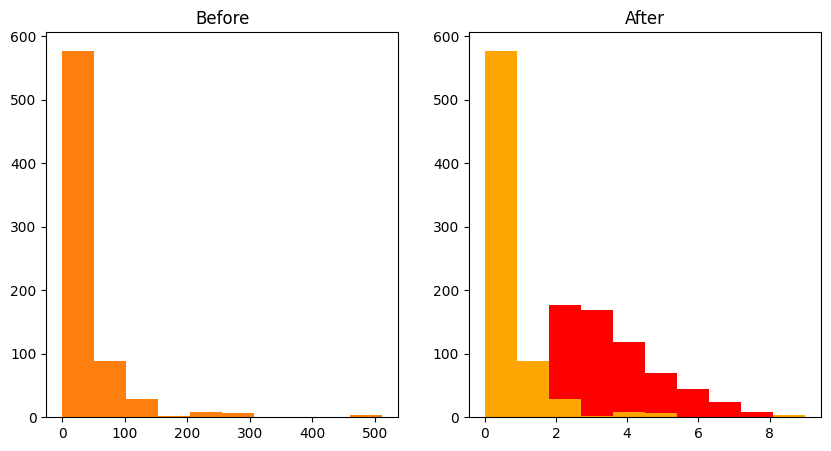

In [40]:
discretize(10,'uniform')